# 14 — Notebook-6 figure replica per (flavor, group, mode) cell

> **Note on R² semantics (added 2026-05-06).** The upstream `cellot/cellot_gpu/scripts/evaluate.py` writes a metric labeled `r2-means` (also `r2-stds`, `r2-pairwise_feat_corrs`) into every `evals.csv`, but the underlying call is `pd.Series.corr(...)` which returns the Pearson correlation coefficient `r ∈ [-1, 1]` — NOT R². Earlier revisions of this notebook consumed those values as if they were R², which silently inflated every reported R² number. This notebook now squares all r2-* metric values immediately after loading each `evals.csv` (in `gather_latent_pivot` and `summary_block`), so every selection of "best IMPACT cell" and every reported summary entry reflects **true R² (coefficient of determination)**. Compare with `08.1_renorm_vs_stale_comparison.ipynb`, which already did this conversion. The scatter plot's `r²(all genes)` and `r²(top 100 DEGs)` annotations are computed locally with `r ** 2` and were already correct.

Per-cell deep dive in the style of `06_cd8_holdout_evaluation.ipynb`. Picks a small set of "cells of interest" from the 5-flavor matrix (default: top 5 by IMPACT R²) and produces, for each:

1. **Summary block** — R² (means, stds, pairwise feat corrs), MMD, k-NN enrichment for both scGen and IMPACT_CellOT, in both data-space and latent-space when available.
2. **Predicted-vs-actual scatter** — one column per model, x = predicted mean expression per gene, y = actual target mean expression. Top 100 DEGs (highest variance in the actual target) shown in red. The curated biomarker panel is labeled with gene symbols. Reports `r²(all genes)` and `r²(top 100 DEGs)` like notebook 6 §5.
3. **UMAP overlay** — one column per model, recomputed in the per-flavor latent space (NOT reusing stale embeddings). Shows actual mouse / actual human held-out / scGen-predicted / IMPACT-predicted held-out. Mirrors notebook 6 §4.
4. **Density plots for curated marker panel** — 12 markers (PTPRC/CD45, CD3E, CD4, CD8A, CD5, CD7, CCR7, NCAM1/CD56, MS4A1/CD20, CD19, CD14, ITGAM/CD11b). For each marker: actual mouse, actual human held-out, scGen-predicted, IMPACT-predicted overlaid as histograms. Markers not in the per-flavor top-1000 show a "not selected" placeholder (this is the failure mode Pearson HVG is supposed to fix).

## Requires data-space evaluations

The scatter and density plots need gene-space (data-space) `imputed.h5ad`, not latent-space. Make sure `scripts/generate_data_space_eval_sbatches.py` has been run and the resulting sbatches have completed for the cells you want to render. Section 1 below reports which cells have data-space evals available.

## Curated biomarker panel

```python
MARKER_PANEL = {
    "PTPRC (CD45)": "ENSG00000081237",
    "CD3E":         "ENSG00000198851",
    "CD4":          "ENSG00000010610",
    "CD8A":         "ENSG00000153563",
    "CD5":          "ENSG00000110448",
    "CD7":          "ENSG00000173762",
    "CCR7":         "ENSG00000126353",
    "NCAM1 (CD56)": "ENSG00000149294",
    "MS4A1 (CD20)": "ENSG00000156738",
    "CD19":         "ENSG00000177455",
    "CD14":         "ENSG00000170458",
    "ITGAM (CD11b)":"ENSG00000169896",
}
```

PTPRC is the headline marker per the 04-20 log: present in `seurat`/`cell_ranger` HVG selections only when batch_key='species' is used, and excluded from the standard log-norm flavors but expected to be rescued by Pearson residuals.

In [1]:
import os
import warnings
from pathlib import Path
from itertools import product

import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import anndata as ad
import scanpy as sc

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0

BASE = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT")
RESULTS_DIR = BASE / "cellot/cellot_gpu/results"
DATA_DIR = BASE / "cellot/cellot_gpu/datasets/speciesot-human-mouse-hvg"
OUT_DIR = BASE / "speciesOT/baseline/analysis/hvg_flavor_nb14_outputs"
FIG_DIR = OUT_DIR / "figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

FLAVORS = ["seurat", "cell_ranger", "seurat_v3", "seurat_v3_paper", "pearson_residuals"]
GROUPS = ["a", "b", "c", "d"]
GROUP_NAMES = {"a": "cd8", "b": "cd8_thymo", "c": "tcell_subtypes", "d": "cd4"}
HOLDOUT_LUT = {
    "a": ["CL:0000625"],
    "b": ["CL:0000625", "CL:0000893"],
    "c": ["CL:0000624", "CL:0000625", "CL:0000893"],
    "d": ["CL:0000624"],
}
MODES = ["ood", "iid"]

DATA_SPACE_SUBDIR = "evals_ood_data_space"
LATENT_SPACE_SUBDIR = "evals_ood_latent_space"

MARKER_PANEL = {
    "PTPRC (CD45)": "ENSG00000081237",
    "CD3E":         "ENSG00000198851",
    "CD4":          "ENSG00000010610",
    "CD8A":         "ENSG00000153563",
    "CD5":          "ENSG00000110448",
    "CD7":          "ENSG00000173762",
    "CCR7":         "ENSG00000126353",
    "NCAM1 (CD56)": "ENSG00000149294",
    "MS4A1 (CD20)": "ENSG00000156738",
    "CD19":         "ENSG00000177455",
    "CD14":         "ENSG00000170458",
    "ITGAM (CD11b)":"ENSG00000169896",
}

print(f"results dir: {RESULTS_DIR}")
print(f"data dir   : {DATA_DIR}")
print(f"outputs    : {OUT_DIR}")
print(f"markers    : {len(MARKER_PANEL)} symbols")

results dir: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results
data dir   : /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/datasets/speciesot-human-mouse-hvg
outputs    : /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/speciesOT/baseline/analysis/hvg_flavor_nb14_outputs
markers    : 12 symbols


## 1. Status of available data-space and latent-space evals

In [2]:
def cell_path(flavor, gk, mode, model, where="data_space"):
    sub = DATA_SPACE_SUBDIR if where == "data_space" else LATENT_SPACE_SUBDIR
    return RESULTS_DIR / f"hvg_{flavor}_{gk}_{mode}" / model / sub

def has_eval(flavor, gk, mode, model, where="data_space"):
    csv = cell_path(flavor, gk, mode, model, where) / "evals.csv"
    return csv.exists() and csv.stat().st_size > 200

def has_imputed(flavor, gk, mode, model, where="data_space"):
    return (cell_path(flavor, gk, mode, model, where) / "imputed.h5ad").exists()

rows = []
for flavor, gk, mode, model in product(FLAVORS, GROUPS, MODES, ["scgen", "impact_cellot"]):
    rows.append({
        "flavor": flavor, "group": gk, "mode": mode, "model": model,
        "latent_eval":   has_eval(flavor, gk, mode, model, "latent_space"),
        "data_eval":     has_eval(flavor, gk, mode, model, "data_space"),
        "imputed_data":  has_imputed(flavor, gk, mode, model, "data_space"),
    })
status = pd.DataFrame(rows)
status_pivot = status.pivot_table(
    index=["flavor", "group", "mode"],
    columns="model",
    values=["latent_eval", "data_eval", "imputed_data"],
    aggfunc="first",
)
print(f"Total cells: {len(status)} ({status['latent_eval'].sum()} have latent eval; "
      f"{status['data_eval'].sum()} have data eval; {status['imputed_data'].sum()} have imputed.h5ad)")
status.to_csv(OUT_DIR / "nb14_status.csv", index=False)
status_pivot.to_csv(OUT_DIR / "nb14_status_pivot.csv")
status_pivot

Total cells: 80 (80 have latent eval; 80 have data eval; 80 have imputed.h5ad)


data_eval        imputed_data        \
model                        impact_cellot scgen impact_cellot scgen   
flavor            group mode                                           
cell_ranger       a     iid           True  True          True  True   
                        ood           True  True          True  True   
                  b     iid           True  True          True  True   
                        ood           True  True          True  True   
                  c     iid           True  True          True  True   
                        ood           True  True          True  True   
                  d     iid           True  True          True  True   
                        ood           True  True          True  True   
pearson_residuals a     iid           True  True          True  True   
                        ood           True  True          True  True   
                  b     iid           True  True          True  True   
                        ood           True  True          True  True   
                  c     iid           True  True          True  True   
                        ood           True  True          True  True   
                  d     iid           True  True          True  True   
                        ood           True  True          True  True   
seurat            a     iid           True  True          True  True   
                        ood           True  True          True  True   
                  b     iid           True  True          True  True   
                        ood           True  True          True  True   
                  c     iid           True  True          True  True   
                        ood           True  True          True  True   
                  d     iid           True  True          True  True   
                        ood           True  True          True  True   
seurat_v3         a     iid           True  True          True  True   
                        ood           True  True          True  True   
                  b     iid           True  True          True  True   
                        ood           True  True          True  True   
                  c     iid           True  True          True  True   
                        ood           True  True          True  True   
                  d     iid           True  True          True  True   
                        ood           True  True          True  True   
seurat_v3_paper   a     iid           True  True          True  True   
                        ood           True  True          True  True   
                  b     iid           True  True          True  True   
                        ood           True  True          True  True   
                  c     iid           True  True          True  True   
                        ood           True  True          True  True   
                  d     iid           True  True          True  True   
                        ood           True  True          True  True   

                               latent_eval        
model                        impact_cellot scgen  
flavor            group mode                      
cell_ranger       a     iid           True  True  
                        ood           True  True  
                  b     iid           True  True  
                        ood           True  True  
                  c     iid           True  True  
                        ood           True  True  
                  d     iid           True  True  
                        ood           True  True  
pearson_residuals a     iid           True  True  
                        ood           True  True  
                  b     iid           True  True  
                        ood           True  True  
                  c     iid           True  True  
                        ood           True  True  
                  d     iid           True  True  
                  

## 2. Pick "cells of interest"

Default: top-N cells by IMPACT_CellOT R² (latent space) where data-space evals are also available. Override `CELLS_OF_INTEREST` below if you want specific cells.

In [3]:
TOP_N = 6  # how many cells to render in this run

# ===========================================
# Override here for a specific list, e.g.:
# CELLS_OF_INTEREST = [
#     ("seurat",            "c", "iid"),
#     ("pearson_residuals", "c", "iid"),
#     ("seurat",            "a", "ood"),
#     ("pearson_residuals", "a", "ood"),
# ]
# Set to None to use top-N by IMPACT R^2.
# ===========================================
CELLS_OF_INTEREST = None

def gather_latent_pivot():
    rows = []
    for f, g, m in product(FLAVORS, GROUPS, MODES):
        for model in ["scgen", "impact_cellot"]:
            csv = cell_path(f, g, m, model, "latent_space") / "evals.csv"
            if not csv.exists() or csv.stat().st_size < 200:
                continue
            df = pd.read_csv(csv)
            sub = df[df["metric"] == "r2-means"]
            if sub.empty:
                continue
            # evaluate.py mislabels Pearson r as r2-* — square here to get true R^2
            agg = (sub.groupby("ncells")["value"].mean()) ** 2
            rows.append({"flavor": f, "group": g, "mode": m, "model": model, "r2": agg.iloc[-1]})
    return pd.DataFrame(rows)

if CELLS_OF_INTEREST is None:
    pivot_df = gather_latent_pivot()
    if pivot_df.empty:
        CELLS_OF_INTEREST = [("seurat", "c", "iid")]
        print("WARNING: no eval data; defaulting to seurat/c/iid")
    else:
        # Pick cells where IMPACT_CellOT has the best R² and BOTH models have data-space imputed
        impact_only = pivot_df[pivot_df["model"] == "impact_cellot"].copy()
        impact_only["impacted_dataspace"] = impact_only.apply(
            lambda r: has_imputed(r["flavor"], r["group"], r["mode"], "impact_cellot") and
                      has_imputed(r["flavor"], r["group"], r["mode"], "scgen"),
            axis=1,
        )
        candidates = impact_only[impact_only["impacted_dataspace"]].sort_values("r2", ascending=False)
        if len(candidates) == 0:
            # Fall back to any cell with imputed.h5ad (even if R² unknown)
            CELLS_OF_INTEREST = []
            for f, g, m in product(FLAVORS, GROUPS, MODES):
                if has_imputed(f, g, m, "impact_cellot") and has_imputed(f, g, m, "scgen"):
                    CELLS_OF_INTEREST.append((f, g, m))
                    if len(CELLS_OF_INTEREST) >= TOP_N:
                        break
        else:
            CELLS_OF_INTEREST = list(zip(
                candidates["flavor"].head(TOP_N),
                candidates["group"].head(TOP_N),
                candidates["mode"].head(TOP_N),
            ))

print(f"Will render {len(CELLS_OF_INTEREST)} cells:")
for c in CELLS_OF_INTEREST:
    print(f"  {c[0]:24s} group={c[1].upper()}  mode={c[2].upper()}")

Will render 6 cells:
  seurat_v3                group=D  mode=OOD
  seurat                   group=C  mode=IID
  pearson_residuals        group=C  mode=IID
  seurat_v3_paper          group=C  mode=IID
  cell_ranger              group=C  mode=IID
  seurat                   group=B  mode=IID


## 3. Helper functions: load data, compute summary, and the four notebook-6-style plots

In [4]:
def load_dataset_and_predictions(flavor, gk, mode):
    """Returns: src (full hvg dataset), actual_target_holdout, scgen_imputed, impact_imputed.
    All in gene space (data_space). Returns None for missing pieces."""
    src_path = DATA_DIR / f"hvg_{flavor}_{gk}_v07.h5ad"
    if not src_path.exists():
        return None, None, None, None
    src = ad.read_h5ad(src_path)
    is_holdout = src.obs["cell_type_ontology_term_id"].astype(str).isin(HOLDOUT_LUT[gk])
    actual_target_holdout = src[(src.obs["condition"] == "human") & is_holdout]

    def maybe_load(model):
        p = cell_path(flavor, gk, mode, model, "data_space") / "imputed.h5ad"
        if not p.exists():
            return None
        try:
            return ad.read_h5ad(p)
        except Exception as e:
            print(f"    warn: could not read {p.name}: {e}")
            return None

    return src, actual_target_holdout, maybe_load("scgen"), maybe_load("impact_cellot")


_R2_METRICS = {"r2-means", "r2-stds", "r2-pairwise_feat_corrs"}


def summary_block(flavor, gk, mode):
    rows = []
    for model in ["scgen", "impact_cellot"]:
        for where in ["latent_space", "data_space"]:
            csv = cell_path(flavor, gk, mode, model, where) / "evals.csv"
            if not csv.exists() or csv.stat().st_size < 200:
                continue
            df = pd.read_csv(csv)
            # evaluate.py mislabels Pearson r as r2-* — square here to get true R^2
            is_r2 = df["metric"].isin(_R2_METRICS)
            df.loc[is_r2, "value"] = df.loc[is_r2, "value"] ** 2
            agg = df.groupby(["metric", "ncells"], as_index=False)["value"].mean()
            largest = agg.sort_values("ncells").drop_duplicates("metric", keep="last")
            for _, r in largest.iterrows():
                rows.append({
                    "model": model, "where": where,
                    "metric": r["metric"], "ncells": int(r["ncells"]),
                    "value": float(r["value"]),
                })
    if not rows:
        return None
    out = pd.DataFrame(rows)
    return out.pivot_table(index=["where", "metric"], columns="model", values="value")


print("Helpers (load + summary) defined.")

Helpers (load + summary) defined.


In [5]:
def to_dense(X):
    if hasattr(X, "todense"):
        return np.asarray(X.todense())
    return np.asarray(X)


def scatter_pred_vs_actual(flavor, gk, mode, src, target_h, scgen_a, impact_a, save_stem):
    """Notebook-6 §5 / GRAPH 2 replica: predicted vs actual mean gene expression.
    Top 100 DEGs in red, biomarkers labeled by symbol."""
    if target_h is None or len(target_h) == 0:
        print("    no actual target cells; skipping scatter")
        return None

    target_df = pd.DataFrame(to_dense(target_h.X), columns=target_h.var_names)
    actual_means = target_df.mean(0)
    gene_var = target_df.var(0)
    top_100_degs = set(gene_var.nlargest(100).index.tolist())

    # Map ENSG -> symbol from MARKER_PANEL
    ensg_to_label = {ensg: label for label, ensg in MARKER_PANEL.items()}

    predicted_means = {}
    if scgen_a is not None:
        predicted_means["scGen"] = pd.DataFrame(
            to_dense(scgen_a.X), columns=scgen_a.var_names
        ).mean(0)
    if impact_a is not None:
        predicted_means["IMPACT_CellOT"] = pd.DataFrame(
            to_dense(impact_a.X), columns=impact_a.var_names
        ).mean(0)

    if not predicted_means:
        print("    no model predictions; skipping scatter")
        return None

    n_models = len(predicted_means)
    fig, axes = plt.subplots(1, n_models, figsize=(6.0 * n_models, 5.5), squeeze=False)
    axes = axes[0]

    for ax, (model_name, pred) in zip(axes, predicted_means.items()):
        shared = actual_means.index.intersection(pred.index)
        x_all = pred[shared].values
        y_all = actual_means[shared].values

        is_deg = np.array([g in top_100_degs for g in shared], dtype=bool)
        is_marker = np.array([g in ensg_to_label for g in shared], dtype=bool)

        r_all = np.corrcoef(x_all, y_all)[0, 1] if len(x_all) > 2 else np.nan
        r2_all_val = r_all ** 2 if not np.isnan(r_all) else np.nan
        r_deg = (np.corrcoef(x_all[is_deg], y_all[is_deg])[0, 1]
                 if is_deg.sum() > 2 else np.nan)
        r2_deg_val = r_deg ** 2 if not np.isnan(r_deg) else np.nan

        # All genes lightly
        ax.scatter(x_all, y_all, s=4, alpha=0.15, c="gray", zorder=2)
        # Top 100 DEGs in red
        ax.scatter(x_all[is_deg], y_all[is_deg], s=20, alpha=0.8, c="red", zorder=5)
        # Markers labeled (over the gray)
        if is_marker.sum() > 0:
            ax.scatter(x_all[is_marker], y_all[is_marker], s=80, alpha=0.95,
                       c="orange", edgecolors="black", linewidths=0.6, zorder=6)
            shared_list = list(shared)
            for i, g in enumerate(shared_list):
                if g in ensg_to_label:
                    ax.annotate(
                        ensg_to_label[g], (x_all[i], y_all[i]),
                        fontsize=9, alpha=0.95,
                        xytext=(5, 5), textcoords="offset points",
                        color="darkorange", fontweight="bold",
                    )

        # y=x line
        lims = [min(x_all.min(), y_all.min()) - 0.05,
                max(x_all.max(), y_all.max()) + 0.05]
        ax.plot(lims, lims, color="grey", linestyle="--", alpha=0.5, lw=1)

        ax.set_xlabel(f"Predicted ({model_name})", fontsize=13)
        ax.set_ylabel(f"Actual human held-out", fontsize=13)
        ax.set_title(model_name, fontsize=14, fontweight="bold")
        ax.text(0.05, 0.95, f"$r^2$(all genes) = {r2_all_val:.3f}\n$r^2$(top 100 DEGs) = {r2_deg_val:.3f}",
                transform=ax.transAxes, va="top", fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

    fig.suptitle(f"Mean gene expression: predicted vs actual\n"
                 f"{flavor} / Group {gk.upper()} / {mode.upper()}",
                 fontsize=12, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    pdf = FIG_DIR / f"{save_stem}_scatter.pdf"
    png = FIG_DIR / f"{save_stem}_scatter.png"
    fig.savefig(pdf, dpi=150, bbox_inches="tight")
    fig.savefig(png, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return png


print("scatter_pred_vs_actual defined.")

scatter_pred_vs_actual defined.


In [6]:
def umap_overlay(flavor, gk, mode, src, target_h, scgen_a, impact_a, save_stem):
    """Notebook-6 §4 replica: recompute UMAP in the per-flavor feature space (gene space here),
    show actual mouse / actual human held-out / scGen pred / IMPACT pred."""
    if target_h is None or len(target_h) == 0:
        print("    no target; skipping umap")
        return None

    is_holdout = src.obs["cell_type_ontology_term_id"].astype(str).isin(HOLDOUT_LUT[gk])
    actual_mouse = src[(src.obs["condition"] == "mouse") & is_holdout]
    actual_human = target_h

    if len(actual_mouse) == 0 or len(actual_human) == 0:
        print("    holdout cells absent; skipping umap")
        return None

    # Stack into one matrix: actual mouse | actual human | scGen pred | IMPACT pred
    blocks = []
    labels = []
    if len(actual_mouse) > 0:
        blocks.append(to_dense(actual_mouse.X)); labels += ["actual mouse"] * len(actual_mouse)
    if len(actual_human) > 0:
        blocks.append(to_dense(actual_human.X)); labels += ["actual human (held-out)"] * len(actual_human)
    if scgen_a is not None and len(scgen_a) > 0:
        blocks.append(to_dense(scgen_a.X)); labels += ["scGen pred"] * len(scgen_a)
    if impact_a is not None and len(impact_a) > 0:
        blocks.append(to_dense(impact_a.X)); labels += ["IMPACT pred"] * len(impact_a)

    X = np.vstack(blocks)
    obs = pd.DataFrame({"label": labels})
    a = ad.AnnData(X=X, obs=obs)

    # Recompute UMAP in this fresh feature space (per the 04-20 rule)
    sc.pp.pca(a, n_comps=min(50, X.shape[1] - 1, X.shape[0] - 1))
    sc.pp.neighbors(a, n_neighbors=min(15, len(a) - 1))
    sc.tl.umap(a)

    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    palette = {"actual mouse": "tab:blue", "actual human (held-out)": "tab:green",
               "scGen pred": "tab:orange", "IMPACT pred": "tab:red"}
    for lab, color in palette.items():
        mask = (a.obs["label"] == lab).values
        if mask.sum() == 0:
            continue
        ax.scatter(a.obsm["X_umap"][mask, 0], a.obsm["X_umap"][mask, 1],
                   s=20, alpha=0.65, c=color, label=f"{lab} (n={mask.sum()})",
                   edgecolors="none")
    ax.set_xlabel("UMAP1"); ax.set_ylabel("UMAP2")
    ax.set_title(f"UMAP overlay (recomputed in gene space)\n{flavor} / Group {gk.upper()} / {mode.upper()}",
                 fontsize=12, fontweight="bold")
    ax.legend(fontsize=9, loc="best")
    fig.tight_layout()
    pdf = FIG_DIR / f"{save_stem}_umap.pdf"
    png = FIG_DIR / f"{save_stem}_umap.png"
    fig.savefig(pdf, dpi=150, bbox_inches="tight")
    fig.savefig(png, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return png


print("umap_overlay defined.")

umap_overlay defined.


In [7]:
def biomarker_density(flavor, gk, mode, src, target_h, scgen_a, impact_a, save_stem):
    """Per-marker density panel: actual mouse, actual human held-out, scGen pred, IMPACT pred."""
    is_holdout = src.obs["cell_type_ontology_term_id"].astype(str).isin(HOLDOUT_LUT[gk])
    actual_mouse = src[(src.obs["condition"] == "mouse") & is_holdout]
    actual_human = target_h

    n_panels = len(MARKER_PANEL)
    n_cols = 4
    n_rows = (n_panels + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.2 * n_rows))
    axes = axes.flatten()

    for ax, (label, ensg) in zip(axes, MARKER_PANEL.items()):
        if ensg not in src.var_names:
            ax.text(0.5, 0.5, f"{label}\nnot in {flavor}\ntop-1000",
                    ha="center", va="center", transform=ax.transAxes,
                    fontsize=10, color="grey", fontstyle="italic")
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_title(label, fontsize=10, color="grey")
            continue
        gi = list(src.var_names).index(ensg)
        traces = []
        if len(actual_mouse) > 0:
            traces.append(("actual mouse",
                          np.asarray(to_dense(actual_mouse.X[:, gi])).ravel(),
                          "tab:blue"))
        if len(actual_human) > 0:
            traces.append(("actual human (held-out)",
                          np.asarray(to_dense(actual_human.X[:, gi])).ravel(),
                          "tab:green"))
        if scgen_a is not None and ensg in scgen_a.var_names:
            gj = list(scgen_a.var_names).index(ensg)
            traces.append(("scGen pred",
                          np.asarray(to_dense(scgen_a.X[:, gj])).ravel(),
                          "tab:orange"))
        if impact_a is not None and ensg in impact_a.var_names:
            gj = list(impact_a.var_names).index(ensg)
            traces.append(("IMPACT pred",
                          np.asarray(to_dense(impact_a.X[:, gj])).ravel(),
                          "tab:red"))

        for name, vals, color in traces:
            if len(vals) == 0:
                continue
            ax.hist(vals, bins=30, density=True, alpha=0.45, color=color, label=name)
        ax.set_title(label, fontsize=10)
        ax.set_xlabel("expression (log-norm)", fontsize=8)
        ax.set_ylabel("density", fontsize=8)
        ax.legend(fontsize=7)
        ax.tick_params(axis="both", labelsize=7)

    # hide leftover axes
    for ax in axes[len(MARKER_PANEL):]:
        ax.axis("off")

    fig.suptitle(f"Biomarker density — {flavor} / Group {gk.upper()} / {mode.upper()}",
                 fontsize=12, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    pdf = FIG_DIR / f"{save_stem}_biomarkers.pdf"
    png = FIG_DIR / f"{save_stem}_biomarkers.png"
    fig.savefig(pdf, dpi=150, bbox_inches="tight")
    fig.savefig(png, dpi=150, bbox_inches="tight")
    plt.close(fig)
    return png


print("biomarker_density defined.")

biomarker_density defined.


## 4. Render every cell-of-interest

For each `(flavor, group, mode)` selected above, this cell:
1. Loads the source dataset and both models' `imputed.h5ad` (data-space).
2. Prints the summary table (R², MMD, etc.).
3. Saves three figures (`*_scatter.{pdf,png}`, `*_umap.{pdf,png}`, `*_biomarkers.{pdf,png}`).
4. Inlines the PNGs for inspection in the notebook.

=== seurat_v3 / Group D / OOD ===


**Summary metrics for `seurat_v3` / Group D / OOD**

model                                impact_cellot    scgen
where        metric                                        
data_space   enrichment-k100                0.4357   0.9022
             enrichment-k50                 0.4357   0.9022
             l2-means                       2.9572   3.5250
             l2-pairwise_feat_corrs         9.4702      NaN
             l2-stds                        2.2722   8.1066
             mmd                            0.0505   0.1026
             r2-means                       0.9186   0.8686
             r2-pairwise_feat_corrs         0.1896   0.0049
             r2-stds                        0.3870   0.5237
latent_space enrichment-k100                0.4320   0.4423
             enrichment-k50                 0.4320   0.4423
             l2-means                       2.9053   4.1478
             l2-pairwise_feat_corrs         9.4338  11.3177
             l2-stds                        2.2571   3.5322
             mmd                            0.0504   0.0602
             r2-means                       0.9184   0.8409
             r2-pairwise_feat_corrs         0.1935   0.0593
             r2-stds                        0.4182   0.1425

ValueError: zero-size array to reduction operation minimum which has no identity

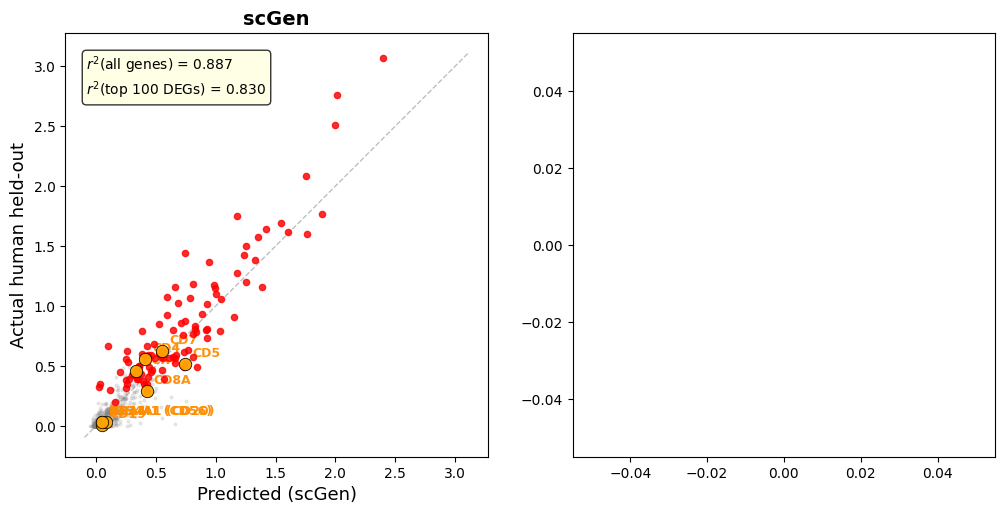

In [8]:
from IPython.display import Image, display, Markdown

rendered_log = []
for flavor, gk, mode in CELLS_OF_INTEREST:
    save_stem = f"cell_{flavor}_{gk}_{mode}"
    print("=" * 78)
    print(f"=== {flavor} / Group {gk.upper()} / {mode.upper()} ===")
    print("=" * 78)

    # Summary block
    summary = summary_block(flavor, gk, mode)
    if summary is not None:
        display(Markdown(f"**Summary metrics for `{flavor}` / Group {gk.upper()} / {mode.upper()}**"))
        display(summary.round(4))
        summary.to_csv(OUT_DIR / f"{save_stem}_summary.csv")
    else:
        print(f"  no summary available for {flavor}/{gk}/{mode}")
        continue

    # Load data
    src, target_h, scgen_a, impact_a = load_dataset_and_predictions(flavor, gk, mode)
    if src is None:
        print(f"  source dataset hvg_{flavor}_{gk}_v07.h5ad missing; skipping figures")
        continue
    if scgen_a is None and impact_a is None:
        print(f"  no data-space imputed.h5ad for either model; skipping figures")
        continue

    # 3 figures
    p_scatter = scatter_pred_vs_actual(flavor, gk, mode, src, target_h, scgen_a, impact_a, save_stem)
    p_umap    = umap_overlay(flavor, gk, mode, src, target_h, scgen_a, impact_a, save_stem)
    p_bio     = biomarker_density(flavor, gk, mode, src, target_h, scgen_a, impact_a, save_stem)

    rendered_log.append({
        "flavor": flavor, "group": gk, "mode": mode,
        "scatter": str(p_scatter) if p_scatter else None,
        "umap":    str(p_umap) if p_umap else None,
        "biomarkers": str(p_bio) if p_bio else None,
    })

    for label, p in [("scatter", p_scatter), ("UMAP", p_umap), ("biomarkers", p_bio)]:
        if p is not None and p.exists():
            print(f"  {label}: {p}")
            display(Image(filename=str(p)))

if rendered_log:
    pd.DataFrame(rendered_log).to_csv(OUT_DIR / "nb14_rendered.csv", index=False)
    print(f"\nDone — rendered {len(rendered_log)} cells. Index: {OUT_DIR / 'nb14_rendered.csv'}")
else:
    print("No cells rendered.")